<a href="https://colab.research.google.com/github/MrMortanya/Astronomy/blob/main/Astronomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data Cleaning & Setup

In [7]:
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/SB%20Close%20Approaches/earth_close_approaches_50yr.csv"


df = pd.read_csv(url)


# 1. I'll begin by cleaning the dataset


# Remove whitespace from column names
df.columns = df.columns.str.strip()


# Remove duplicate rows
df.drop_duplicates(inplace=True)


# Convert the date column to datetime
df["cd"] = pd.to_datetime(df["cd"])


# Create a Year column
df["Year"] = df["cd"].dt.year


# Keep only the columns needed
df = df[["des", "Year", "cd", "v_rel", "dist"]]


# Convert columns to numeric
df["v_rel"] = pd.to_numeric(df["v_rel"], errors="coerce")
df["dist"] = pd.to_numeric(df["dist"], errors="coerce")


# Remove rows with missing values
df.dropna(subset=["v_rel", "dist"], inplace=True)


# Sort by year
df.sort_values("Year", inplace=True)


# Reset the index
df.reset_index(drop=True, inplace=True)


# Verify the cleaned dataset
print(df.info())
print(df.describe())


df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186255 entries, 0 to 186254
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   des     186255 non-null  object        
 1   Year    186255 non-null  int32         
 2   cd      186255 non-null  datetime64[ns]
 3   v_rel   186255 non-null  float64       
 4   dist    186255 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), object(1)
memory usage: 6.4+ MB
None
                Year                             cd          v_rel  \
count  186255.000000                         186255  186255.000000   
mean     2005.851472  2006-05-11 23:40:33.334299648      12.905789   
min      1976.000000            1976-01-01 04:35:00       0.056485   
25%      1994.000000            1994-06-20 00:17:00       7.764031   
50%      2009.000000            2009-06-13 08:27:00      11.904336   
75%      2019.000000            2019-04-26 20:06:00      16.913653   

,des,Year,cd,v_rel,dist
0,2022 MP,1976,1976-01-06 02:21:00,12.516923,0.297340
1,2022 AD,1976,1976-01-06 01:34:00,6.944628,0.077247
2,2018 PX23,1976,1976-01-05 14:57:00,10.391798,0.168066
3,2009 MW,1976,1976-01-05 04:34:00,17.420158,0.353316
4,2003 AF23,1976,1976-01-05 01:55:00,14.534417,0.109900


# Research Question:
“Has the relative velocity of closely approaching asteroids changed over the past 50 years? What might this suggest about the risk of close encounters?”


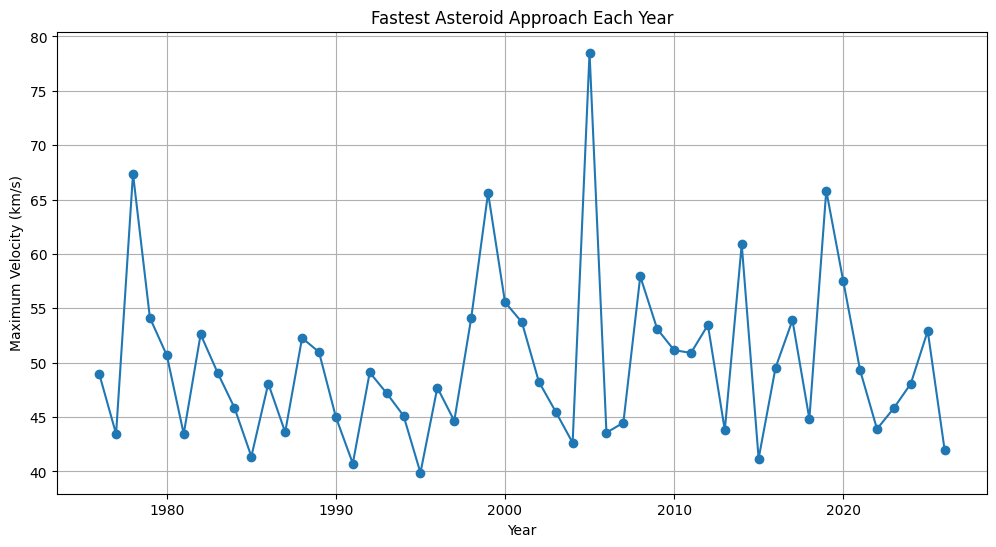

        Year        des                  cd      dist      v_rel
185888  2026   2026 JN4 2026-05-15 13:44:00  0.000014  23.192931
182599  2025  2025 UC11 2025-10-30 12:11:00  0.000044  11.364929
149619  2020   2020 VT4 2020-11-13 17:21:00  0.000045  13.427120
181989  2025    2025 TF 2025-10-01 00:49:00  0.000045  20.876114
177167  2024    2024 XA 2024-12-01 09:46:00  0.000052  13.565976
173843  2024   2024 LH1 2024-06-06 14:02:00  0.000054  17.404073
176529  2024   2024 UG9 2024-10-30 12:42:00  0.000059  20.304681
147716  2020    2020 QG 2020-08-16 04:09:00  0.000062  12.330867
156019  2021   2021 UA1 2021-10-25 03:07:00  0.000063  15.835007
178130  2025   2025 BP6 2025-01-26 01:10:00  0.000065  21.046976


In [ ]:
# 3. Similarly to the closest by year, I'll create a line plot demonstrating the speed of the asteroids against the year.

fastest_each_year = df.groupby("Year")["v_rel"].max()

plt.figure(figsize=(12,6))

plt.plot(fastest_each_year.index,
         fastest_each_year.values,
         marker='o')

plt.title("Fastest Asteroid Approach Each Year")
plt.xlabel("Year")
plt.ylabel("Maximum Velocity (km/s)")
plt.grid(True)


plt.show()

closest = df.nsmallest(10, "dist")

print(closest[["Year", "des", "cd", "dist", "v_rel"]])
